<a href="https://colab.research.google.com/github/njaiganesh1994/ATTR_MISHMASH/blob/master/Startup_success_failure_project_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [8]:
from google.colab import files
uploaded = files.upload()

Saving big_startup_success_dataset.csv to big_startup_success_dataset.csv


In [12]:
df = pd.read_csv('/content/big_startup_success_dataset.csv')

In [ ]:
df.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


In [14]:
df.shape

(66368, 14)

In [15]:
df.describe(include="all")

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
count,66368,66367,61310,63220,66368,66368,59410,57821,58338,58340,66368.000000,51147,66344,66368
unique,66368,66102,61191,27296,18896,4,137,311,1092,5111,NaN,3978,4817,4518
top,/organization/zynergy-projects-services,Spire,http://www.askforoffer.com,Software,-,operating,USA,CA,SF Bay Area,San Francisco,NaN,2012-01-01,2014-01-01,2014-01-01
freq,1,4,5,3995,12785,53034,37601,12900,8804,3526,NaN,2730,565,483
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.732522,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.360251,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN


# Missing Values :

In [16]:
missing = pd.DataFrame({

    "Missing": df.isnull().sum(),

    "Percent":
    (df.isnull().sum()/len(df)*100).round(2)

})

missing.sort_values(
    "Percent",
    ascending=False
)

,Missing,Percent
founded_at,15221,22.93
state_code,8547,12.88
region,8030,12.10
city,8028,12.10
country_code,6958,10.48
homepage_url,5058,7.62
category_list,3148,4.74
first_funding_at,24,0.04
permalink,0,0.00
name,1,0.00


# Create Target Variable :

In [17]:
df = df[df["status"].isin(
    ["acquired","ipo","closed","operating"]
)]

df["target"] = np.where(
    df["status"].isin(["acquired","ipo"]),
    1,
    0
)

print(df["target"].value_counts())

target
0    59272
1     7096
Name: count, dtype: int64


In [ ]:
# Meaning:

# 1 = acquired or ipo

# 0 = operating or closed

# Check Class Distribution :

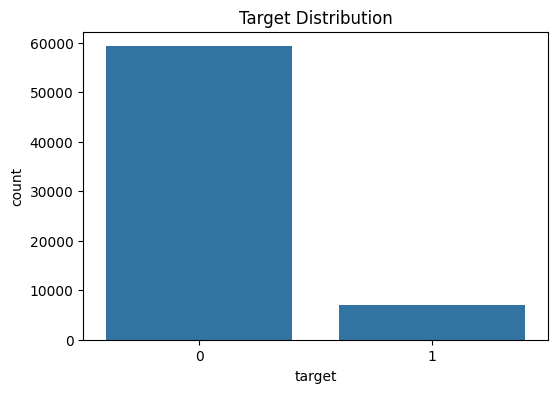

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Target Distribution")

plt.show()

# Convert Funding :

In [19]:
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .replace("-", np.nan)
)

df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

# Convert Dates :

In [20]:
date_cols = [
    "founded_at",
    "first_funding_at"
]

for col in date_cols:

    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

# Create Company Age :

In [21]:
df["company_age"] = (
    df["first_funding_at"]
    -
    df["founded_at"]
).dt.days / 365

df["company_age"] = (
    df["company_age"]
    .clip(lower=0)
)

# Create Funding Stage :

In [22]:
def get_stage(x):

    if pd.isna(x):
        return "Unknown"

    elif x <= 1:
        return "Seed"

    elif x <= 3:
        return "Early"

    elif x <= 6:
        return "Growth"

    else:
        return "Late"

df["stage"] = (
    df["funding_rounds"]
    .apply(get_stage)
)

# Create Sector :

In [23]:
df["sector"] = (
    df["category_list"]
    .fillna("Unknown")
    .str.split("|")
    .str[0]
)

In [24]:
print("Missing founded_at:",
      df["founded_at"].isna().sum())

print("Missing company_age:",
      df["company_age"].isna().sum())

Missing founded_at: 15225
Missing company_age: 15248


In [ ]:
# round(
#     df["company_age"].isna().mean()*100,
#     2
# )

In [25]:
df

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,target,company_age,stage,sector
0,/organization/-fame,#fame,http://livfame.com,Media,10000000.0,operating,IND,16,Mumbai,Mumbai,1,NaT,2015-01-05,2015-01-05,0,NaN,Seed,Media
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000.0,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14,0,0.000000,Early,Application Platforms
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878.0,operating,NaN,NaN,NaN,NaN,1,NaT,2014-01-30,2014-01-30,0,NaN,Seed,Apps
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000.0,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19,0,1.213699,Seed,Curated Web
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,NaN,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24,0,4.561644,Seed,Software
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66363,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,Enterprise Software,1587301.0,operating,CHN,22,Beijing,Beijing,1,NaT,2012-04-01,2012-04-01,0,NaN,Seed,Enterprise Software
66364,/organization/zzzzapp-com,Zzzzapp Wireless ltd.,http://www.zzzzapp.com,Advertising|Mobile|Web Development|Wireless,114304.0,operating,HRV,15,Split,Split,4,2012-05-13,2011-11-01,2014-03-01,0,0.000000,Growth,Advertising
66365,/organization/Áeron,ÁERON,http://www.aeron.hu/,NaN,NaN,operating,NaN,NaN,NaN,NaN,1,2011-01-01,2014-08-01,2014-08-01,0,3.583562,Seed,Unknown
66366,/organization/Ôasys-2,Ôasys,http://www.oasys.io/,Consumer Electronics|Internet of Things|Teleco...,18192.0,operating,USA,CA,SF Bay Area,San Francisco,1,2014-01-01,2015-01-01,2015-01-01,0,1.000000,Seed,Consumer Electronics


# EDA : Funding vs Target :

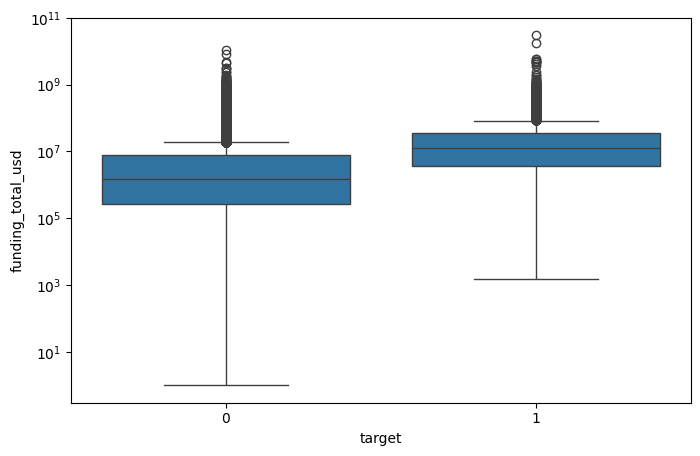

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="funding_total_usd",
    data=df
)

plt.yscale("log")

plt.show()

# Top Sectors :

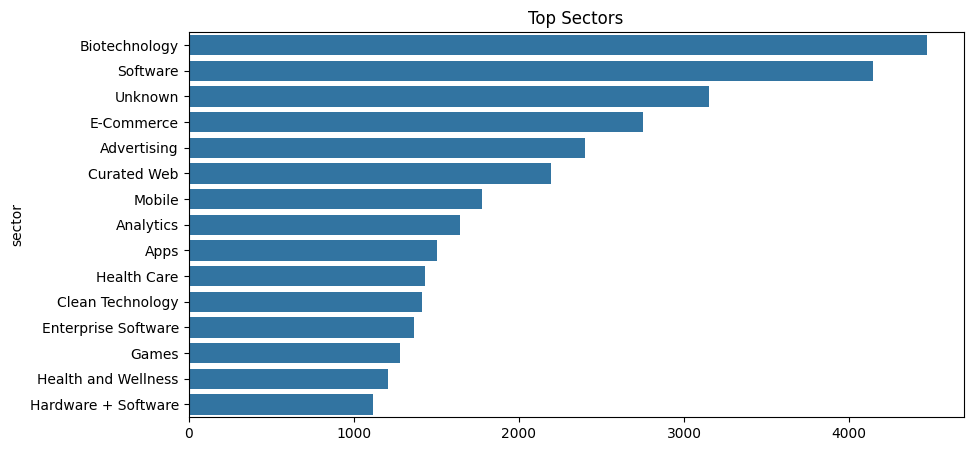

In [27]:
top_sector = (
    df["sector"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_sector.values,
    y=top_sector.index
)

plt.title("Top Sectors")

plt.show()

# Success vs Non-Success Distribution :

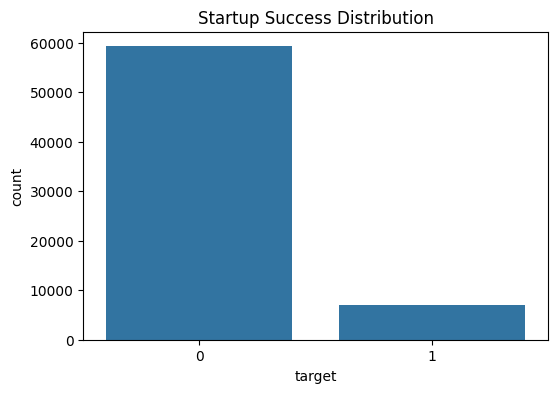

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Startup Success Distribution")

plt.show()

In [29]:
success_rate = round(
    df['target'].mean()*100,
    2
)

print(f"Success Rate: {success_rate}%")

Success Rate: 10.69%


In [ ]:
# only 10.69% became IPO/acquired.

# Status Distribution :

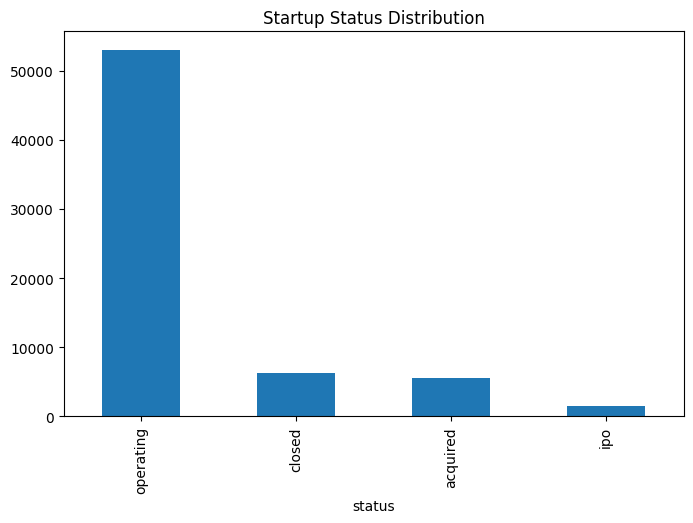

In [30]:
plt.figure(figsize=(8,5))

df["status"].value_counts().plot(
    kind="bar"
)

plt.title("Startup Status Distribution")

plt.show()

# Funding Distribution :

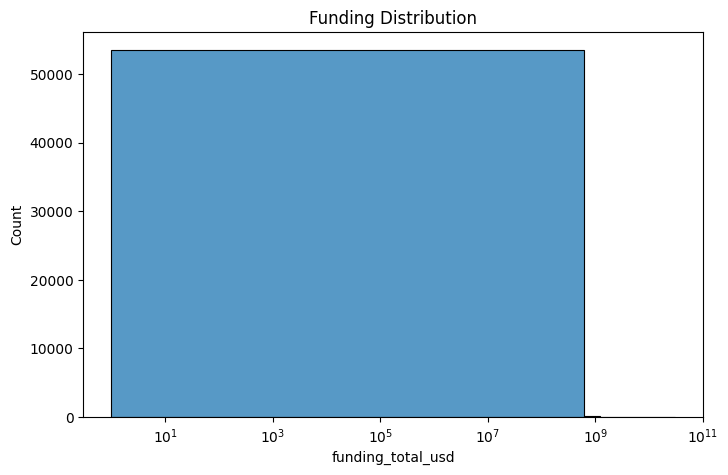

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["funding_total_usd"],
    bins=50
)

plt.xscale("log")

plt.title("Funding Distribution")

plt.show()

# Funding vs Success :

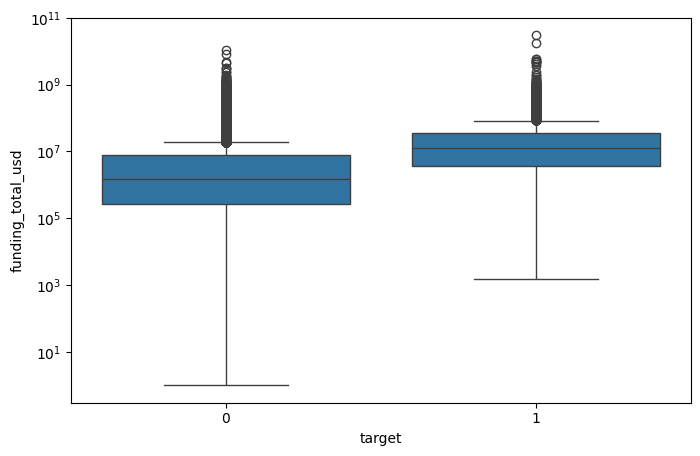

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="funding_total_usd",
    data=df
)

plt.yscale("log")

plt.show()

In [ ]:
# Do successful startups receive more funding?

# Average Funding by Target :

In [33]:
funding_summary = df.groupby(
    "target"
)["funding_total_usd"].mean()

funding_summary

,funding_total_usd
target,
0,1.361409e+07
1,5.544613e+07


# Company Age Distribution :

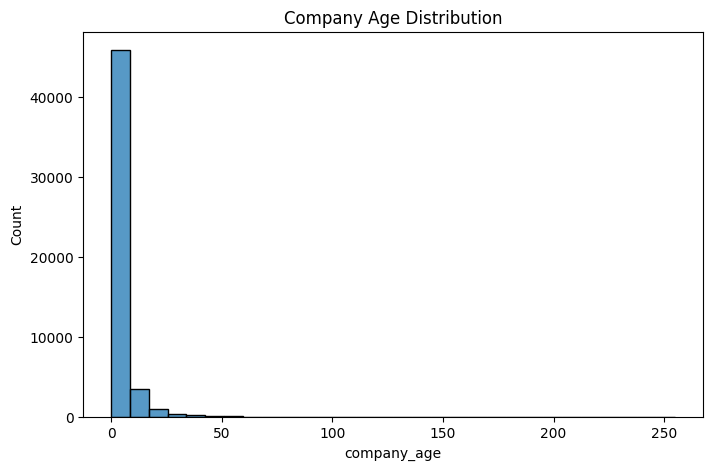

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["company_age"],
    bins=30
)

plt.title(
    "Company Age Distribution"
)

plt.show()

In [ ]:
# How old are startups before first funding?

# Company Age vs Success :

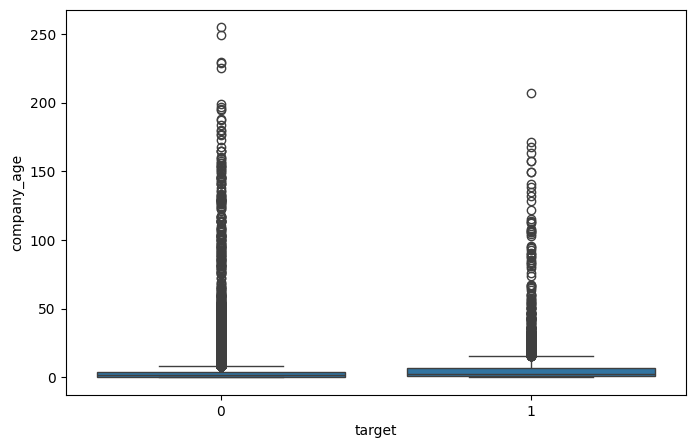

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="company_age",
    data=df
)

plt.show()

In [ ]:
# Do younger startups attract better outcomes?

# Stage-wise Success Rate :

In [36]:
stage_success = pd.crosstab(
    df["stage"],
    df["target"],
    normalize="index"
)*100

stage_success

target,0,1
stage,,
Early,85.923492,14.076508
Growth,79.341498,20.658502
Late,76.046025,23.953975
Seed,92.206630,7.793370


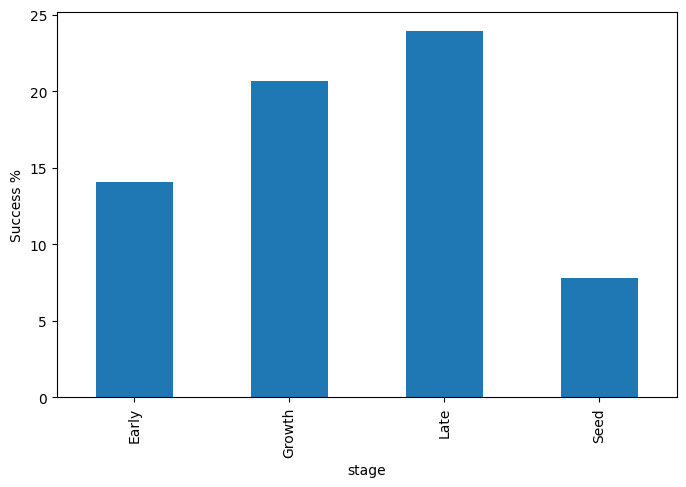

In [37]:
stage_success[1].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel(
    "Success %"
)

plt.show()

In [ ]:
# Which stage has highest success?

# Top Startup Sector :

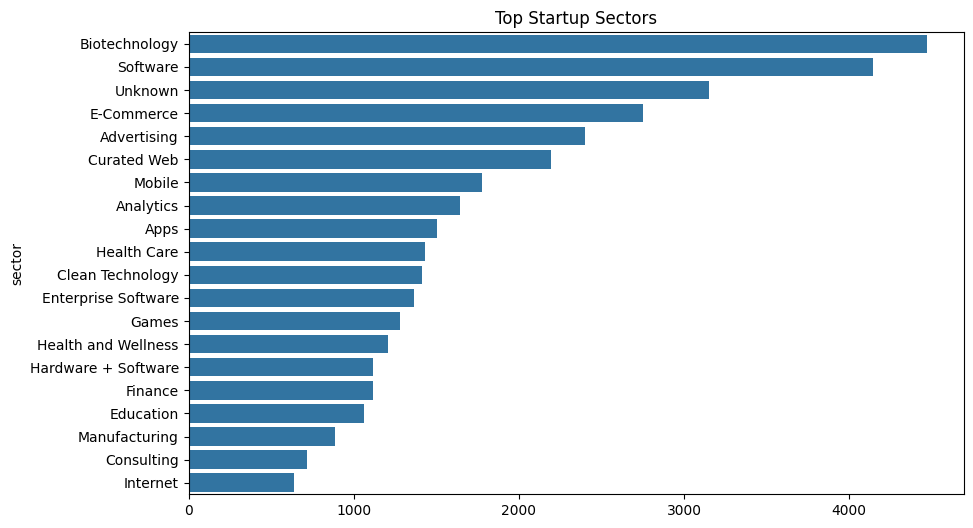

In [38]:
top_sector = (
    df["sector"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sector.values,
    y=top_sector.index
)

plt.title("Top Startup Sectors")

plt.show()

# Sector Success Rate :

In [39]:
sector_success = (
    df.groupby("sector")["target"]
    .mean()
    .sort_values(
        ascending=False
    )
)

sector_success.head(20)

,target
sector,
Real Estate Investors,1.000000
Physicians,1.000000
Pervasive Computing,1.000000
EDA Tools,1.000000
Television,0.666667
Minerals,0.666667
Meeting Software,0.600000
Communications Hardware,0.513514
Opinions,0.500000


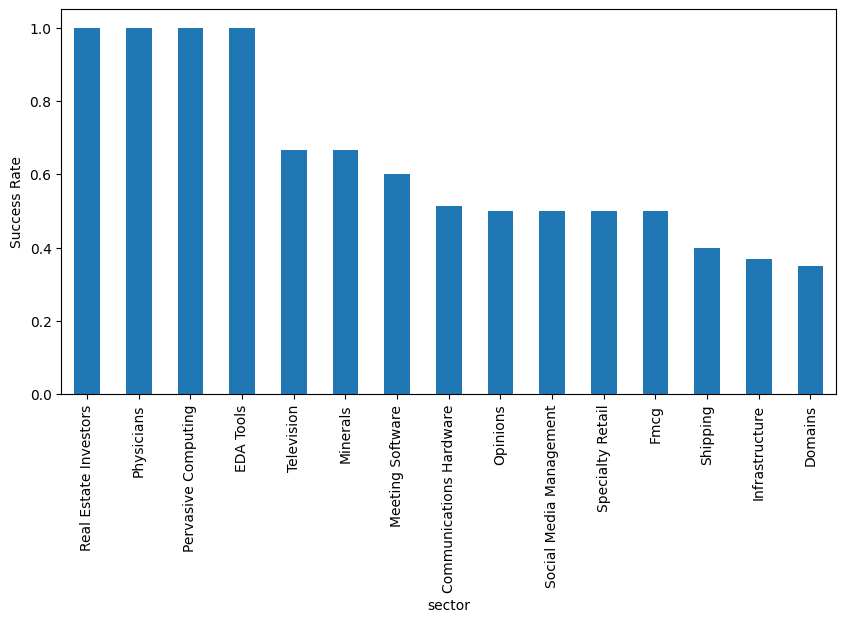

In [40]:
sector_success.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel(
    "Success Rate"
)

plt.show()

In [ ]:
# Which industries succeed most?

# Country Distribution :

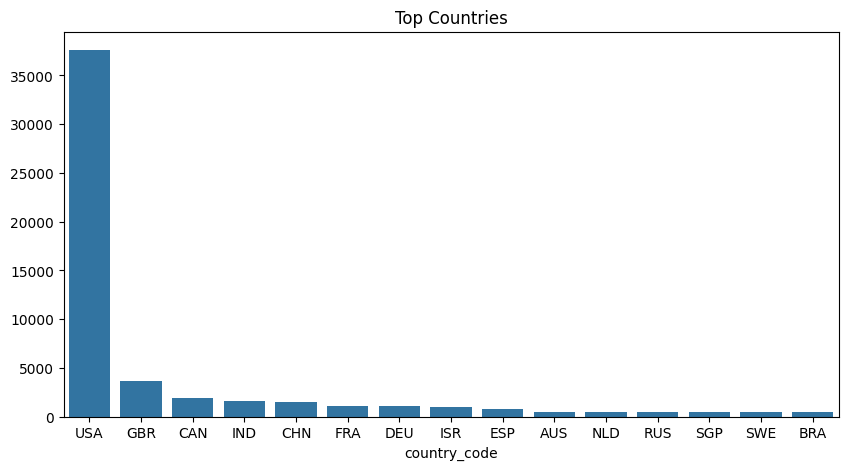

In [41]:
top_country = (
    df["country_code"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_country.index,
    y=top_country.values
)

plt.title("Top Countries")

plt.show()

# Country Success Rate :

In [42]:
country_success = (
    df.groupby("country_code")
    ["target"]
    .mean()
    .sort_values(
        ascending=False
    )
)

country_success.head(20)

,target
country_code,
MAF,1.000000
BMU,0.285714
TTO,0.200000
USA,0.140023
ISR,0.132642
URY,0.125000
HRV,0.125000
CAN,0.123117
BEL,0.097561


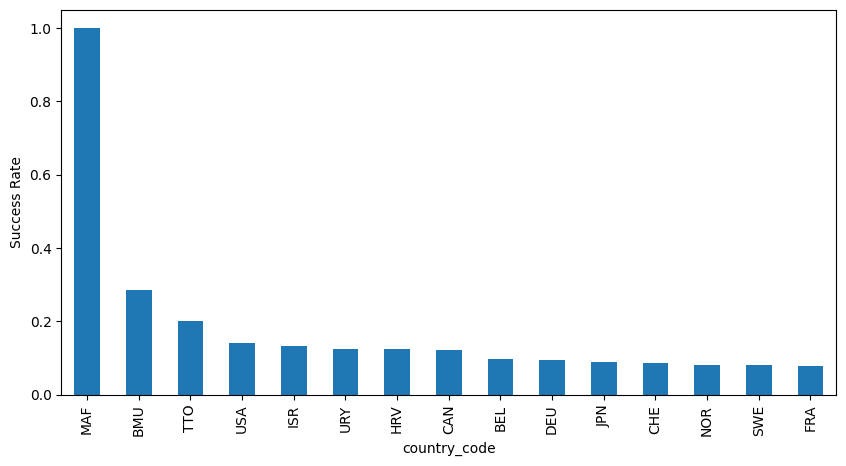

In [43]:
country_success.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel(
    "Success Rate"
)

plt.show()

In [ ]:
# Which countries produce more successful startups?

# Top Regions :

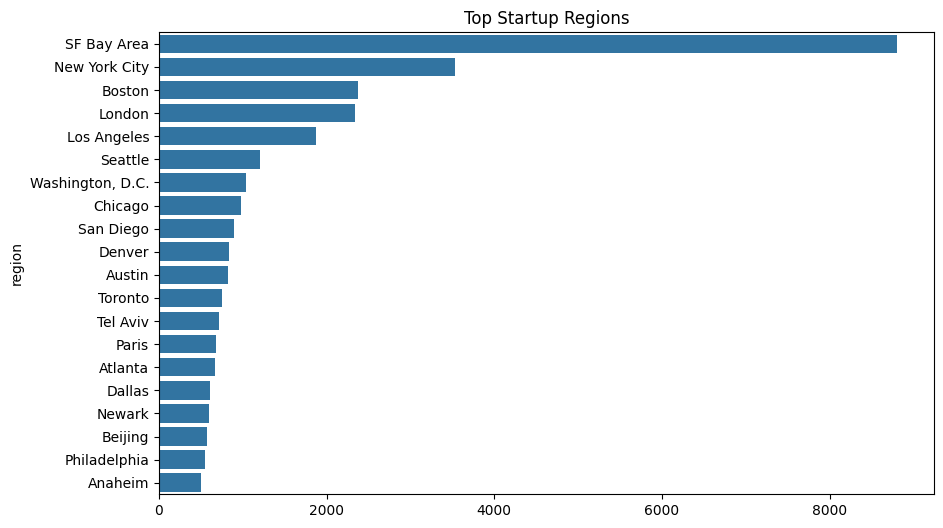

In [44]:
top_region = (
    df["region"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_region.values,
    y=top_region.index
)

plt.title("Top Startup Regions")

plt.show()

# Region Success Rate :

In [45]:
region_success = (
    df.groupby("region")
    ["target"]
    .mean()
    .sort_values(
        ascending=False
    )
)

region_success.head(20)

,target
region,
Vevey,1.000000
Muenchen,1.000000
Ilford,1.000000
Homburg,1.000000
HRV - Other,1.000000
New Westminster,1.000000
MAF - Other,1.000000
MaroÃºli,1.000000
Danderyd,1.000000


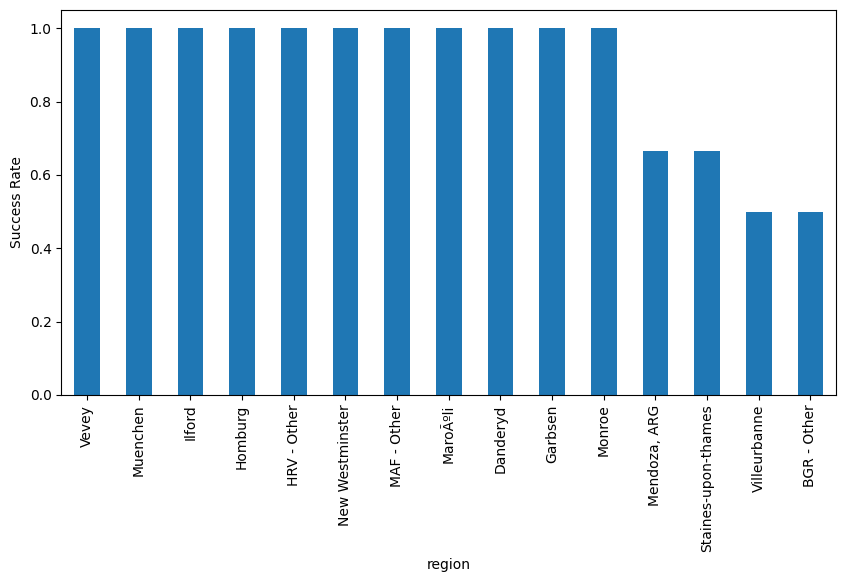

In [46]:
region_success.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel(
    "Success Rate"
)

plt.show()

# Funding Rounds Distribution :

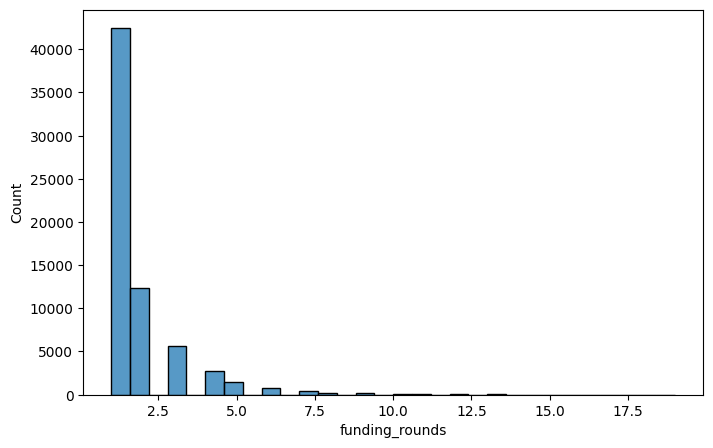

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["funding_rounds"],
    bins=30
)

plt.show()

# Funding Rounds vs Success :

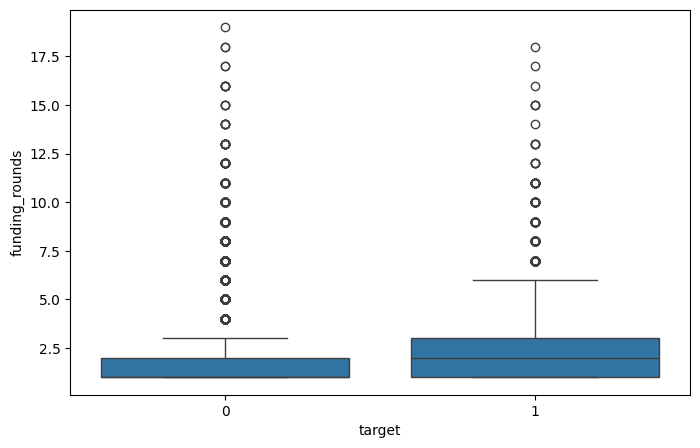

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="funding_rounds",
    data=df
)

plt.show()

In [ ]:
# Do successful startups survive more funding rounds?

# Correlation Heatmap:

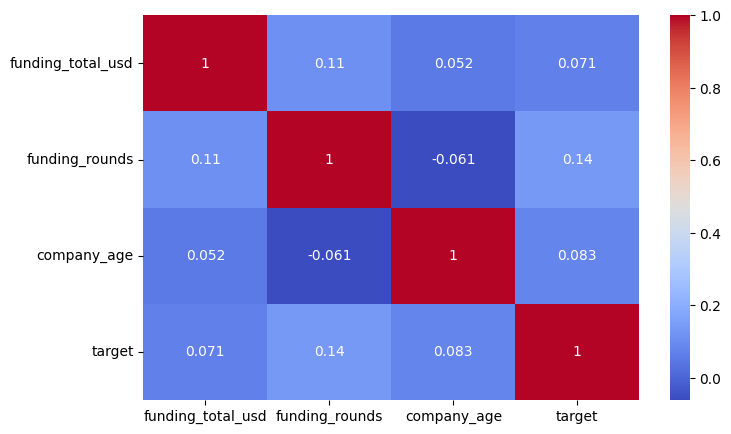

In [49]:
num_df = df[[
    "funding_total_usd",
    "funding_rounds",
    "company_age",
    "target"
]]

plt.figure(figsize=(8,5))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Success Rate by Funding Quartile :

In [50]:
df["funding_bucket"] = pd.qcut(
    df["funding_total_usd"],
    q=4,
    duplicates="drop"
)

In [51]:
funding_success = (
    df.groupby(
        "funding_bucket"
    )["target"]
    .mean()*100
)

funding_success

,target
funding_bucket,
"(0.999, 335623.5]",1.963273
"(335623.5, 2000000.0]",6.162303
"(2000000.0, 10000000.0]",13.040484
"(10000000.0, 30079503000.0]",25.665714


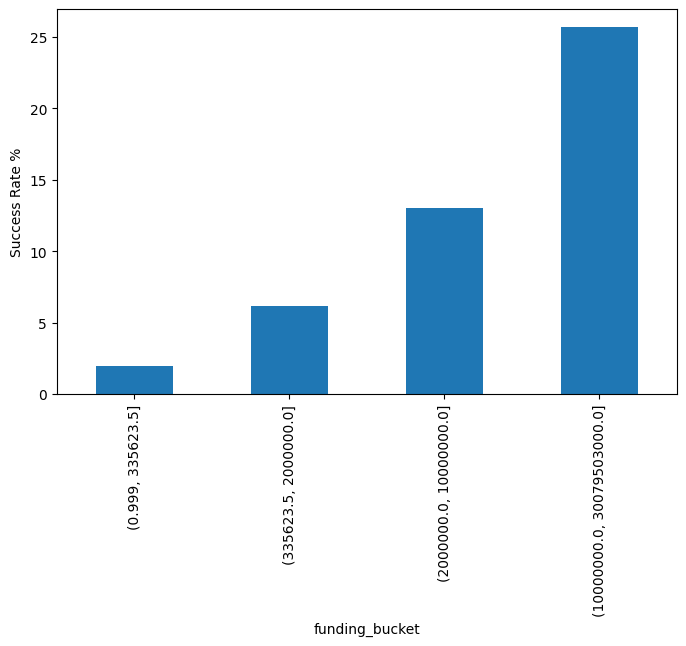

In [52]:
funding_success.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel(
    "Success Rate %"
)

plt.show()

# Top 10 Insights Table :

In [53]:
insights = pd.DataFrame({

    "Metric":[

        "Total Startups",

        "Success Rate",

        "Average Funding",

        "Median Funding",

        "Average Age",

        "Unique Sectors",

        "Unique Countries",

        "Unique Regions"
    ],

    "Value":[

        len(df),

        round(df.target.mean()*100,2),

        round(df.funding_total_usd.mean(),2),

        round(df.funding_total_usd.median(),2),

        round(df.company_age.mean(),2),

        df.sector.nunique(),

        df.country_code.nunique(),

        df.region.nunique()
    ]
})

insights

,Metric,Value
0,Total Startups,66368.00
1,Success Rate,10.69
2,Average Funding,18478604.04
3,Median Funding,2000000.00
4,Average Age,3.82
5,Unique Sectors,729.00
6,Unique Countries,137.00
7,Unique Regions,1092.00


# Success Rate By Stage :

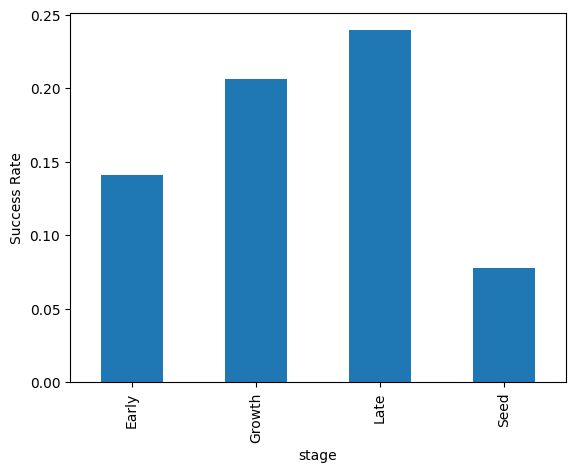

In [54]:
stage_success = pd.crosstab(
    df["stage"],
    df["target"],
    normalize="index"
)

stage_success[1].plot(
    kind="bar"
)

plt.ylabel(
    "Success Rate"
)

plt.show()

# Select Features :

In [55]:
features = [

    "funding_total_usd",

    "funding_rounds",

    "company_age",

    "sector",

    "country_code",

    "state_code",

    "region",

    "stage"
]

X = df[features]

y = df["target"]

# Train Test Split :

In [56]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(53094, 8)
(13274, 8)


# Define Numeric & Categorical Columns :

In [57]:
num_cols = [

    "funding_total_usd",

    "funding_rounds",

    "company_age"
]

cat_cols = [

    "sector",

    "country_code",

    "state_code",

    "region",

    "stage"
]

# Preprocessing :

In [58]:
numeric_transformer = Pipeline([

    ("imputer",
     SimpleImputer(
         strategy="median"
     ))
])

categorical_transformer = Pipeline([

    ("imputer",
     SimpleImputer(
         strategy="most_frequent"
     )),

    ("onehot",
     OneHotEncoder(
         handle_unknown="ignore"
     ))
])

preprocessor = ColumnTransformer([

    (
        "num",
        numeric_transformer,
        num_cols
    ),

    (
        "cat",
        categorical_transformer,
        cat_cols
    )
])

# Random Forest (Main Model) :

In [59]:
rf_pipeline = Pipeline([

    (
        "preprocess",
        preprocessor
    ),

    (
        "model",

        RandomForestClassifier(

            n_estimators=300,

            max_depth=15,

            class_weight="balanced",

            random_state=42,

            n_jobs=-1
        )
    )
])

rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['funding_total_usd',
                                                   'funding_rounds',
                                                   'company_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sector', 'country_code',
                                                   'state_code', 'region',
                                                   'stage'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

# Evaluate Random Forest :

In [60]:
rf_pred = rf_pipeline.predict(
    X_test
)

rf_prob = rf_pipeline.predict_proba(
    X_test
)[:,1]

In [61]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     11855
           1       0.21      0.64      0.32      1419

    accuracy                           0.71     13274
   macro avg       0.58      0.68      0.57     13274
weighted avg       0.86      0.71      0.76     13274

ROC AUC: 0.7333360975303831


# Logistic Regression :

In [62]:
lr_pipeline = Pipeline([

    (
        "preprocess",
        preprocessor
    ),

    (
        "model",

        LogisticRegression(

            max_iter=1000,

            class_weight="balanced"
        )
    )
])

lr_pipeline.fit(
    X_train,
    y_train
)

lr_prob = lr_pipeline.predict_proba(
    X_test
)[:,1]

# Gradient Boosting :

In [72]:
gb_pipeline = Pipeline([

    (
        "preprocess",
        preprocessor
    ),

    (
        "model",

        GradientBoostingClassifier(
            random_state=42
        )
    )
])

gb_pipeline.fit(
    X_train,
    y_train
)

gb_prob = gb_pipeline.predict_proba(
    X_test
)[:,1]

In [69]:
from xgboost import XGBClassifier

In [71]:
xgb_pipeline = Pipeline([

    (
        "preprocess",
        preprocessor
    ),

    (
        "model",

        XGBClassifier(
            random_state=42
        )
    )
])

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_prob = xgb_pipeline.predict_proba(
    X_test
)[:,1]

# Compare Models :

In [74]:
results = pd.DataFrame({

    "Model":[

        "Random Forest",

        "Logistic Regression",

        "Gradient Boosting",
        "XG Boost"
    ],

    "ROC_AUC":[

        roc_auc_score(
            y_test,
            rf_prob
        ),

        roc_auc_score(
            y_test,
            lr_prob
        ),

        roc_auc_score(
            y_test,
            gb_prob
        ),

        roc_auc_score(
            y_test,
            xgb_prob
        )
    ]
})

results.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
3,XG Boost,0.762150
2,Gradient Boosting,0.757676
0,Random Forest,0.733336
1,Logistic Regression,0.717416


# Feature Importance :

In [65]:
rf_model = rf_pipeline.named_steps["model"]

feature_names = (

    rf_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)

importance = pd.DataFrame({

    "Feature":
    feature_names,

    "Importance":
    rf_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance.head(20)

,Feature,Importance
0,num__funding_total_usd,0.264886
2,num__company_age,0.086657
1,num__funding_rounds,0.083198
2200,cat__stage_Seed,0.069978
841,cat__country_code_USA,0.039606
2198,cat__stage_Growth,0.035212
2197,cat__stage_Early,0.024544
677,cat__sector_Unknown,0.019044
70,cat__sector_Biotechnology,0.017428
1271,cat__region_Boston,0.012838


# Plot Important Factors :

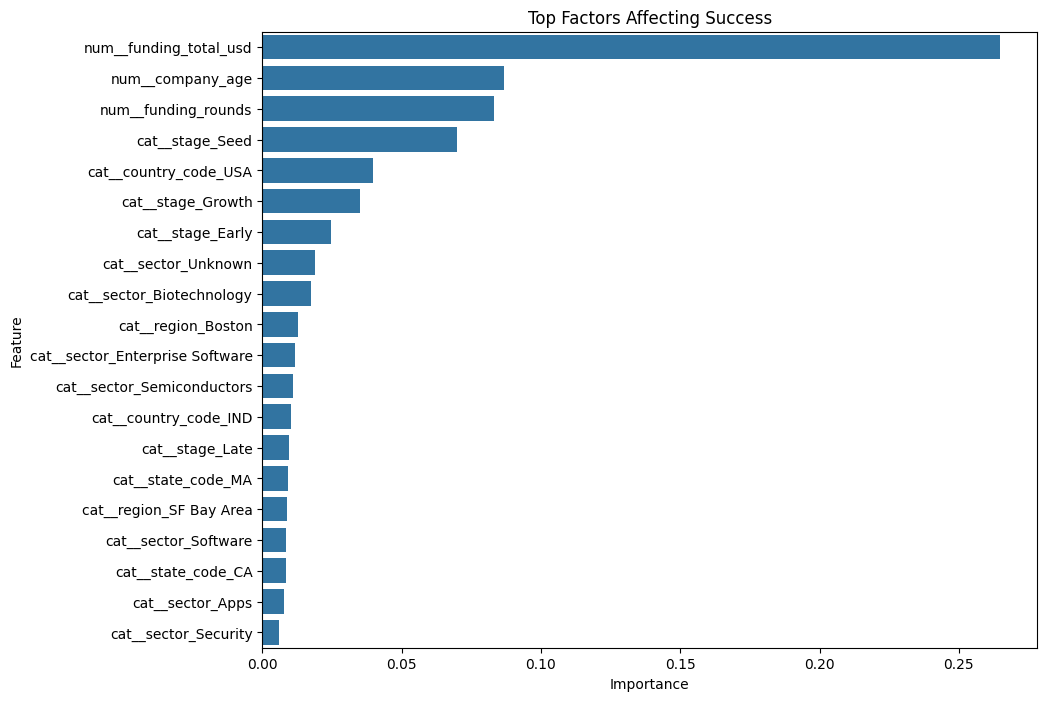

In [66]:
top20 = importance.head(20)

plt.figure(
    figsize=(10,8)
)

sns.barplot(

    x="Importance",

    y="Feature",

    data=top20
)

plt.title(
    "Top Factors Affecting Success"
)

plt.show()

# Predict New Startup :

In [67]:
new_startup = pd.DataFrame({

    "funding_total_usd":[5000000],

    "funding_rounds":[2],

    "company_age":[1.5],

    "sector":["FinTech"],

    "country_code":["USA"],

    "state_code":["CA"],

    "region":["SF Bay Area"],

    "stage":["Early"]
})

In [68]:
prob = rf_pipeline.predict_proba(
    new_startup
)[0][1]

print(
    f"Success Probability = {prob:.2%}"
)

Success Probability = 57.82%


In [ ]:
## Note :

# The most valuable insights usually come from:

# Sector Success Rate
# Country Success Rate
# Funding Quartile Success Rate
# Funding Rounds vs Success
# Stage-wise Success Rate
# Feature Importance from Random Forest after modeling.

##Deployment Methodology

We will look at wrapping the trained model into a pickle format and consecutively wrap it in API like Restful. Further, we will also look at the containarisation of the model and the related api call into a docker. Further we would bring the docker container into the cloud for its deployment.
We would create a workflow for training the model.
Further, we would setup a CI/CD pipeline for smooth continuous improvement and continuous development process.

The primary workflow looks like below:

                    Historical Startup Data
                              │
                              ▼
                  Data Preprocessing and Data Wrangling
                              │
                              ▼
                     Feature Engineering Process
                              │
                              ▼
      ┌──────────────────────────────────────────┐
      │ Candidate Model Training                 │
      │ • Logistic Regression                    │
      │ • Random Forest                          │
      │ • Gradient Boosting                      │
      │ • XGBoost                                │
      │                                          │
      └──────────────────────────────────────────┘
                              │
                              ▼
        Model Performance validation and performance comparison
                              │
                    Best Performing Model
                              │
                              ▼
                Serialize Complete ML Pipeline
                              │
                              ▼
                  REST API (FastAPI / Flask)
                              │
                              ▼
                   Docker Container Deployment
                              │
                              ▼
                       Cloud deployment
                      
                              │
                              ▼
              Monitoring, Logging & Data Collection
                              │
                              ▼
        Periodic Retraining and Model Re-evaluation

###Conclusion
